# Hybrid RAG with LangGraph

This is the standard RAG pipeline from `1_standard_rag/5_standard_rag_langgraph.ipynb`, upgraded to **hybrid retrieval** with the fusion step broken out as its own node. The graph has three steps: **`retrieve`** runs dense (pgvector) and sparse (BM25 via `pg_textsearch`) search, **`reranking`** fuses the two ranked lists with RRF, and **`generate`** answers from the fused context.

```
question --> [ retrieve: dense (pgvector) + sparse (BM25) ] --> [ reranking: RRF fuse ] --> [ generate ] --> answer
```

Each step is an independent node, so you can change retrieval, reranking, or generation without touching the others - that is the point of modelling RAG as a graph.

Prerequisites:

- Run `1_standard_rag/4_ocr_chunk_store_pgvector.ipynb` - it populates the `rag_documents` collection **and** builds the `bm25_chunks_idx` index.
- `pg_textsearch` installed (see `1_install_pgvector`), and the self-hosted Qwen embedding + LLM services reachable (see `day2skk/0_install_emb_model` and `day1skk/1a_install_llm`).

## Dependencies

The dense side (`langchain-postgres`, `langchain-openai` for the remote embedding model), the BM25 side (`psycopg`), and generation (`langchain-openai`, `langgraph`) - all in `../requirements.txt`:

```bash
pip install -r requirements.txt
```

## Configuration

Same shared `var.env` as the other notebooks (`day2skk/var.env`). The embedding and LLM both point at the self-hosted vLLM services; the defaults reach them via in-cluster DNS.

```dotenv
PG_HOST=pgvector
PG_PORT=5432
PG_USER=raguser
PG_PASSWORD=change-me-please
PG_DB=ragdb

# embedding (self-hosted Qwen3-Embedding-4B, must match ingestion)
EMB_MODEL=Qwen/Qwen3-Embedding-4B
EMB_BASE_URL=http://qwen3-emb-4b.default.svc.cluster.local/v1
EMB_API_KEY=sk-...

# LLM (self-hosted Qwen3.5-9B on vLLM)
LLM_MODEL=Qwen/Qwen3.5-9B
LLM_BASE_URL=http://qwen-35-9b.default.svc.cluster.local/v1
LLM_API_KEY=sk-...
```

In [1]:
import os
import psycopg
from dotenv import load_dotenv

load_dotenv("../var.env")   # shared env file at day2skk/var.env

PG_HOST = os.environ.get("PG_HOST", "pgvector")
PG_PORT = os.environ.get("PG_PORT", "5432")
PG_USER = os.environ.get("PG_USER", "raguser")
PG_PASSWORD = os.environ.get("PG_PASSWORD", "change-me-please")
PG_DB = os.environ.get("PG_DB", "ragdb")

CONNECTION = f"postgresql+psycopg://{PG_USER}:{PG_PASSWORD}@{PG_HOST}:{PG_PORT}/{PG_DB}"
COLLECTION_NAME = "rag_documents"    # collection ingested in notebook 4
INDEX_NAME = "bm25_chunks_idx"       # BM25 index created in notebook 4

# Embedding model: self-hosted Qwen3-Embedding-4B on vLLM. MUST match ingestion.
EMB_MODEL = os.environ.get("EMB_MODEL", "Qwen/Qwen3-Embedding-4B")
EMB_BASE_URL = os.environ.get("EMB_BASE_URL", "http://qwen3-emb-4b.default.svc.cluster.local/v1")
EMB_API_KEY = os.environ.get("EMB_API_KEY", "sk-dhU11z5FIjXQ8TLXpwDotpGetP21CQv3")

# LLM: self-hosted Qwen3.5-9B on vLLM (see day1skk/1a_install_llm).
LLM_MODEL = os.environ.get("LLM_MODEL", "Qwen/Qwen3.5-9B")
LLM_BASE_URL = os.environ.get("LLM_BASE_URL", "http://qwen-35-9b.default.svc.cluster.local/v1")
LLM_API_KEY = os.environ.get("LLM_API_KEY", "sk-dhU11z5FIjXQ8TLXpwDotpGetP21CQv3")

# psycopg connection for the BM25 SQL
conn = psycopg.connect(
    f"host={PG_HOST} port={PG_PORT} dbname={PG_DB} user={PG_USER} password={PG_PASSWORD}"
)
conn.autocommit = True

print("pgvector:", f"{PG_HOST}:{PG_PORT}/{PG_DB}")
print("collection:", COLLECTION_NAME)
print("embeddings:", EMB_MODEL, "@", EMB_BASE_URL)
print("LLM:", LLM_MODEL, "@", LLM_BASE_URL)

pgvector: 103.125.91.67:5432/ragdb
collection: rag_documents
embeddings: Qwen/Qwen3-Embedding-4B @ http://103.125.91.66/v1
LLM: Qwen/Qwen3.5-9B @ http://103.125.91.43/v1


## Connect to the chunks (dense + sparse)

The dense side opens the `rag_documents` collection with the **same embedding model** as ingestion. The sparse side confirms `pg_textsearch` and the `bm25_chunks_idx` index exist and grabs the collection id. Both cover the identical chunks notebook 4 stored.

In [2]:
from langchain_openai import OpenAIEmbeddings
from langchain_postgres import PGVector

# Same embedding model as ingestion (notebook 4): self-hosted Qwen3-Embedding-4B.
embeddings = OpenAIEmbeddings(
    model=EMB_MODEL,
    base_url=EMB_BASE_URL,
    api_key=EMB_API_KEY,
    check_embedding_ctx_length=False,
)
vector_store = PGVector(
    embeddings=embeddings,
    collection_name=COLLECTION_NAME,
    connection=CONNECTION,
    use_jsonb=True,
)

with conn.cursor() as cur:
    cur.execute("SELECT 1 FROM pg_extension WHERE extname = 'pg_textsearch';")
    if cur.fetchone() is None:
        raise RuntimeError("pg_textsearch is not installed. See 1_install_pgvector.")
    cur.execute("SELECT 1 FROM pg_indexes WHERE indexname = %s;", (INDEX_NAME,))
    if cur.fetchone() is None:
        raise RuntimeError(f"Index {INDEX_NAME!r} not found. Run notebook 4 first.")
    cur.execute("SELECT uuid FROM langchain_pg_collection WHERE name = %s;", (COLLECTION_NAME,))
    row = cur.fetchone()
    if row is None:
        raise RuntimeError(f"Collection {COLLECTION_NAME!r} not found. Run notebook 4 first.")
    COLLECTION_ID = row[0]

print("dense + sparse ready; collection id:", COLLECTION_ID)

dense + sparse ready; collection id: e2f35ef9-0c1b-4002-a80b-3367dbf31c12


## Retrieval and reranking helpers

Three small helpers back the graph nodes: `dense_search` (pgvector similarity), `sparse_search` (BM25 via the `bm25_chunks_idx` index), and `rrf_fuse` (**Reciprocal Rank Fusion**, which merges ranked lists using ranks only). The graph below wires them into **two separate nodes** - a `retrieve` node that runs both searches, and a `reranking` node that fuses their results.

In [3]:
def dense_search(query: str, k: int = 5) -> list[str]:
    return [d.page_content for d in vector_store.similarity_search(query, k=k)]


def sparse_search(query: str, k: int = 5) -> list[str]:
    sql = (
        "SELECT document "
        "FROM langchain_pg_embedding "
        "WHERE collection_id = %(cid)s "
        "ORDER BY document <@> to_bm25query(%(q)s, %(idx)s) "   # reads bm25_chunks_idx; best first
        "LIMIT %(k)s;"
    )
    with conn.cursor() as cur:
        cur.execute(sql, {"cid": COLLECTION_ID, "q": query, "idx": INDEX_NAME, "k": k})
        return [r[0] for r in cur.fetchall()]


def rrf_fuse(ranked_lists: list[list[str]], rrf_k: int = 60) -> list[tuple[str, float]]:
    scores: dict[str, float] = {}
    for ranked in ranked_lists:
        for rank, key in enumerate(ranked):
            scores[key] = scores.get(key, 0.0) + 1.0 / (rrf_k + rank + 1)
    return sorted(scores.items(), key=lambda kv: kv[1], reverse=True)

## The LLM

Generation uses the **self-hosted Qwen3.5-9B** model served by vLLM (OpenAI-compatible API), the same model as the standard-RAG notebook. Only the retriever differs between the two notebooks; the LLM is identical.

In [4]:
from langchain_openai import ChatOpenAI

# Points at the self-hosted Qwen3.5-9B vLLM endpoint (OpenAI-compatible API).
llm = ChatOpenAI(
    model=LLM_MODEL,
    base_url=LLM_BASE_URL,
    api_key=LLM_API_KEY,
    temperature=0,
    extra_body={
        "chat_template_kwargs": {"enable_thinking": False}
    }
)

## Graph state and nodes

The pipeline now has **three** nodes, and the state carries the intermediate ranked lists between them:

- **`retrieve`** runs dense and sparse search and stores the two ranked lists (`dense`, `sparse`) in the state.
- **`reranking`** reads those two lists, fuses them with RRF, and keeps the top chunks as `context`.
- **`generate`** answers using only that `context` (unchanged from the standard-RAG notebook).

Pulling fusion out into its own `reranking` node makes it a clean swap point - you could replace RRF with a cross-encoder reranker or an LLM-based reranker later without touching retrieval or generation.

In [5]:
from typing import TypedDict, List


class RAGState(TypedDict):
    question: str
    dense: List[str]     # dense (pgvector) ranked list, produced by retrieve
    sparse: List[str]    # sparse (BM25) ranked list, produced by retrieve
    context: List[str]   # fused top chunks, produced by reranking
    answer: str


def retrieve(state: RAGState) -> dict:
    # Run both retrievers and keep their ranked lists separate for the reranking node.
    dense = dense_search(state["question"], k=5)
    sparse = sparse_search(state["question"], k=5)
    print(f"[retrieve] dense={len(dense)} sparse={len(sparse)} candidates")
    return {"dense": dense, "sparse": sparse}


def reranking(state: RAGState) -> dict:
    # Fuse the two ranked lists with Reciprocal Rank Fusion, then keep the top chunks.
    fused = rrf_fuse([state["dense"], state["sparse"]], rrf_k=60)
    context = [text for text, _ in fused[:4]]
    print(f"[reranking] RRF fused -> {len(context)} chunks")
    return {"context": context}


def generate(state: RAGState) -> dict:
    context_text = "\n\n".join(state["context"])
    messages = [
        ("system",
         "You are a helpful assistant. Answer the question using ONLY the context below. "
         "If the answer is not in the context, say you don't know."),
        ("human", f"Context:\n{context_text}\n\nQuestion: {state['question']}"),
    ]
    answer = llm.invoke(messages).content
    return {"answer": answer}

## Build the graph

Now a four-step line: `START -> retrieve -> reranking -> generate -> END`. Retrieval and fusion are separate nodes, so each can change independently.

/opt/conda/lib/python3.11/site-packages/langgraph/checkpoint/base/__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


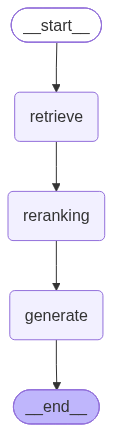

In [6]:
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

builder = StateGraph(RAGState)
builder.add_node("retrieve", retrieve)
builder.add_node("reranking", reranking)
builder.add_node("generate", generate)

builder.add_edge(START, "retrieve")
builder.add_edge("retrieve", "reranking")
builder.add_edge("reranking", "generate")
builder.add_edge("generate", END)

hybrid_rag = builder.compile()
display(Image(hybrid_rag.get_graph().draw_mermaid_png()))

## Ask a question

`invoke` runs hybrid-retrieve then generate. The answer is grounded in chunks chosen by *both* semantic and keyword relevance.

In [7]:
result = hybrid_rag.invoke({"question": "What is Cloudeka?"})

print("ANSWER:\n", result["answer"])
print("\nCONTEXT USED:")
for i, chunk in enumerate(result["context"], 1):
    print(f"  {i}. {chunk[:100]!r}")

[retrieve] dense=5 sparse=5 candidates
[reranking] RRF fused -> 4 chunks
ANSWER:
 Based on the context provided, **Cloudeka** is a Cloud Computing platform that offers various cloud services, including computing, storage, and networking. It supports self-service through a dashboard service portal, allowing users to configure settings, create projects, check billing, and view or create rules within their organization. Users can utilize these services to either develop new applications or run existing ones on the platform.

CONTEXT USED:
  1. 'Service Portal Cloudeka\nCloudeka is a Cloud Computing platform that provides various cloud services '
  2. 'Introduction\nPrevious Location Next Create Deka VPN\n[Guidance for Enterprise Cloudeka API List](http'
  3. 'Introduction\nTo create Deka LLM in the Service Portal Cloudeka, you need to know the project type be'
  4. 'Documentation\n[Guidance for Enterprise Deka Metal](https://docs.cloudeka.ai/)'


### Try your own question

Hybrid retrieval is especially helpful when the question contains a specific keyword or name that a purely semantic search might blur - BM25 pulls that chunk in, and RRF keeps it near the top.

In [8]:
question = "What is Deka Box?"
print(hybrid_rag.invoke({"question": question})["answer"])

[retrieve] dense=5 sparse=5 candidates
[reranking] RRF fused -> 4 chunks
Based on the context provided, **Deka Box** is S3 Browser compatible storage objects spread across three data center locations. It features dedicated tenant portals for controlling buckets, access keys, and configuration. It is described as a cost-effective data store designed to handle large amounts of data with unlimited storage capacity.


## Recap

- **Hybrid RAG as three nodes:** `retrieve` (dense pgvector + sparse BM25) -> `reranking` (RRF fusion) -> `generate`. Fusion is now its own node, not buried inside retrieval.
- Because RAG is a **graph**, each step is swappable in isolation - change the retrievers, the fusion/reranking strategy, or the LLM without touching the rest.
- The `retrieve` node passes its two ranked lists through the state; the `reranking` node consumes them and produces the final `context`.
- Both retrievers read the **same chunks** from notebook 4 (embeddings + the `bm25_chunks_idx` index), so results are directly fusible.
- Hybrid retrieval gives the best of both worlds: **semantic recall from vectors + exact-term precision from BM25** - and the standalone `reranking` node is where you would later plug in a stronger reranker.

That completes the hybrid RAG pipeline: **ingest once (vectors + BM25) -> retrieve -> rerank -> generate.**